In [1]:
from datasets import load_dataset
from data_processing import (
    _select_usable_examples,
)
from inter_band_distance import run_inter_band_distance_analysis
from MOGP_model import run_target_band_ablation_study
import importlib
import gp_internal_diagnostics
importlib.reload(gp_internal_diagnostics)
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
dset_plasticc = load_dataset(
    "MultimodalUniverse/plasticc",
    streaming=True,
    split="train",
).with_format("numpy")


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
selected_examples, scanned_examples = _select_usable_examples(
    iter(dset_plasticc),
    target_band="u",
    n_objects=500,
    max_examples_to_scan=1000,
    min_points=8,
)

In [9]:
from inter_band_distance import run_inter_band_distance_analysis
rows = []

for example in selected_examples:
    lc = example["lightcurve"]

    time = np.asarray(lc["time"], dtype=float)
    flux = np.asarray(lc["flux"], dtype=float)
    band = np.asarray(lc["band"])

    valid = np.isfinite(time) & np.isfinite(flux)
    time = time[valid]
    flux = flux[valid]
    band = band[valid]

    peak_time = time[np.argmax(np.abs(flux))]

    rows.extend({
        "object_id": example["object_id"],
        "obj_type": example["obj_type"],
        "band": band_i,
        "time_relative_to_peak": time_i - peak_time,
        "flux": flux_i,
    } for time_i, flux_i, band_i in zip(time, flux, band))

observations_df = pd.DataFrame(rows)

distances, correlations = run_inter_band_distance_analysis(
    observations_df,
    output_dir="inter_band_distance_outputs",
)

Hypothesis: Classes for which empirical inter-band distance increases more consistently with wavelength separation should benefit more from wavelength-based cross-band information transfer.

The following code aims at proving this hypothesis.

In [18]:
from data_processing import _select_usable_examples
from MOGP_model import run_target_band_ablation_study

# Format: (auxiliary_band, target_band)
transfer_pairs = [
    ("g", "u"),
    ("u", "g"),
    ("g", "r"),
    ("r", "g"),
    ("i", "r"),
    ("r", "i"),
    ("z", "i"),
    ("i", "z"),
]

target_bands = sorted({target for _, target in transfer_pairs})

# Select target-compatible objects once per target band.
selected_by_target = {}

for target_band in target_bands:
    examples, scanned = _select_usable_examples(
        iter(dset_plasticc),
        target_band=target_band,
        n_objects=500,
        max_examples_to_scan=1000,
        min_points=8,
    )

    selected_by_target[target_band] = examples

    print(
        f"Target {target_band}: selected {len(examples)}, "
        f"scanned {scanned}"
    )

Target g: selected 500, scanned 502
Target i: selected 500, scanned 500
Target r: selected 500, scanned 500
Target u: selected 500, scanned 500
Target z: selected 500, scanned 500


In [19]:
all_bands = ("u", "g", "r", "i", "z")

# Results keyed by (auxiliary_band, target_band).
results_by_pair = {}
skipped_by_pair = {}

for auxiliary_band, target_band in transfer_pairs:
    pair = (auxiliary_band, target_band)
    pair_results = []
    skipped = []

    aux_band_ratios = {
        band: float(band == auxiliary_band)
        for band in all_bands
    }

    for object_idx, example in enumerate(selected_by_target[target_band]):
        try:
            result = run_target_band_ablation_study(
                example,
                target_band=target_band,
                bands=all_bands,
                aux_band_ratios=aux_band_ratios,
                models=(
                    "mogp_real_wavelength",
                    "mogp_independent_band_control",
                ),
                random_state=object_idx,
                mogp_gp_kwargs={
                    "n_restarts_optimizer": 0,
                    "print_kernel": False,
                },
            )
        except ValueError as error:
            skipped.append({
                "object_id": example["object_id"],
                "class": example["obj_type"],
                "reason": str(error),
            })
            continue

        pair_results.append(result)

    results_by_pair[pair] = pair_results
    skipped_by_pair[pair] = skipped

    print(
        f"{auxiliary_band} → {target_band}: "
        f"completed {len(pair_results)}, skipped {len(skipped)}"
    )

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 2000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.war

g → u: completed 500, skipped 0


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(

u → g: completed 500, skipped 0


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn

...

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 20.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(

z → i: completed 500, skipped 0


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


i → z: completed 500, skipped 0


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(

In [20]:
from pathlib import Path
from inter_band_distance import run_band_pair_transfer_analysis

base_output_dir = Path("inter_band_distance_pair_outputs")
distance_csv = "inter_band_distance_outputs/inter_band_distances.csv"

pair_summaries = {}
pair_object_results = {}

for pair, pair_results in results_by_pair.items():
    auxiliary_band, target_band = pair
    pair_name = f"{auxiliary_band}_to_{target_band}"
    output_dir = base_output_dir / pair_name

    object_results, class_summary = run_band_pair_transfer_analysis(
        pair_results,
        transfer_pairs=[pair],
        distances=distance_csv,
        output_dir=output_dir,
        support_window=0.25,
    )

    pair_object_results[pair] = object_results
    pair_summaries[pair] = class_summary

SNIa g->u: D=0.05897654927, support=2.333333333, median_delta_nlpd=-5.053797062e-06
AGN g->u: D=0.3577864793, support=2, median_delta_nlpd=-0.0213838598
SNII g->u: D=0.06213380892, support=2, median_delta_nlpd=0.003094607708
TDE g->u: D=0.1404372672, support=1.666666667, median_delta_nlpd=0.105922833
SNIbc g->u: D=0.08719028441, support=1.666666667, median_delta_nlpd=-0.0001562773921
SLSN-I g->u: D=0.1020934185, support=2.666666667, median_delta_nlpd=0.0143612781
SNIax g->u: D=0.1454580849, support=9.866666667, median_delta_nlpd=0.01148708983
M-dwarf g->u: D=0.2166250007, support=10.2, median_delta_nlpd=1.074468516e-05
KN g->u: D=0.2966536502, support=1.666666667, median_delta_nlpd=3.924328013e-06
SNIa-91bg g->u: D=0.1567127562, support=1.666666667, median_delta_nlpd=4.45901609e-06
EB g->u: D=0.1162561005, support=10.33333333, median_delta_nlpd=-1.053623038e-06
RRL g->u: D=0.3694836326, support=10.66666667, median_delta_nlpd=0.02622299763
SNIa u->g: D=0.05897654927, support=2.5, median

In [6]:
from inter_band_distance import (
    build_mogp_vs_model_d_pointwise,
    aggregate_mogp_vs_model_d,
)

pair_pointwise = build_mogp_vs_model_d_pointwise(all_pair_results)
pair_objects, pair_classes = aggregate_mogp_vs_model_d(pair_pointwise)

for class_name in ["TDE", "RRL", "AGN"]:
    selected = pair_objects[pair_objects["class"] == class_name]

    print(f"\n{class_name}")
    print(selected[
        [
            "delta_nlpd_object",
            "delta_sharp_object",
            "delta_std_error_object",
            "delta_rmse_object",
        ]
    ].describe())


TDE
       delta_nlpd_object  delta_sharp_object  delta_std_error_object  \
count          42.000000           42.000000               42.000000   
mean            0.165206            0.232470               -0.067264   
std             0.383293            0.250320                0.320748   
min            -1.298363           -0.011433               -1.490892   
25%             0.032347            0.079009               -0.095213   
50%             0.105923            0.176546               -0.014860   
75%             0.240303            0.295693                0.002799   
max             1.364342            1.303527                1.048329   

       delta_rmse_object  
count          42.000000  
mean            0.543933  
std             9.374713  
min           -43.378415  
25%            -1.311344  
50%             0.011684  
75%             2.485370  
max            29.648388  

RRL
       delta_nlpd_object  delta_sharp_object  delta_std_error_object  \
count           5.000000  

In [5]:
from inter_band_distance import print_class_gain_diagnostics

m_dwarf = print_class_gain_diagnostics(
    object_level,
    class_summary,
    class_label="M-dwarf",
    precision=12,
)

       delta_nlpd_object  delta_sharp_object  delta_std_error_object  \
count    39.000000000000     39.000000000000         39.000000000000   
mean     -0.734562222772     -0.008517848683         -0.726044374088   
std       2.606584484384      0.112018144381          2.574046272574   
min     -11.911426815779     -0.411093723345        -11.983709062404   
25%      -0.075274970691     -0.035400871816         -0.041425228064   
50%       0.000002169382      0.000002648391          0.000000342432   
75%       0.023233965744      0.019838847254          0.008412629480   
max       0.213927833819      0.233038670548          0.180099415129   

       delta_rmse_object  
count    39.000000000000  
mean     -9.735140205248  
std      36.483084016997  
min    -160.182236972272  
25%      -0.922142262802  
50%      -0.000034265042  
75%       0.075510344641  
max      31.553893321377  

Missing values:
delta_nlpd_object         0
delta_sharp_object        0
delta_std_error_object    0
dtype: 

In [6]:
m_dwarf = object_level[object_level["class"] == "M-dwarf"]

worst_objects = m_dwarf.nsmallest(
    10,
    "delta_nlpd_object",
)

print(worst_objects[
    [
        "object_id",
        "n_test_points",
        "nlpd_mogp_object",
        "nlpd_model_d_object",
        "delta_nlpd_object",
        "delta_sharp_object",
        "delta_std_error_object",
        "rmse_mogp_object",
        "rmse_model_d_object",
        "delta_rmse_object",
    ]
].to_string(index=False))

object_id  n_test_points  nlpd_mogp_object  nlpd_model_d_object  delta_nlpd_object  delta_sharp_object  delta_std_error_object  rmse_mogp_object  rmse_model_d_object  delta_rmse_object
   330300             11         15.146909             3.235482         -11.911427            0.072282              -11.983709         59.636260             4.670936         -54.965323
   338999             11         13.201734             2.321476         -10.880258           -0.411094              -10.469164         16.034140             1.298304         -14.735837
   297005             11        107.907183           104.013347          -3.893836            0.014661               -3.908497        153.841954           145.042152          -8.799802
 89274370              5         46.786457            44.912339          -1.874118            0.018864               -1.892983         64.598238            64.325284          -0.272954
121429195              5          4.991358             4.771841          -0

In [7]:
worst_id = worst_objects.iloc[0]["object_id"]

worst_points = pointwise[
    (pointwise["class"] == "M-dwarf") &
    (pointwise["object_id"] == worst_id)
].copy()

worst_points["z_mogp"] = (
    (worst_points["y_true"] - worst_points["mu_mogp"])
    / worst_points["sigma_mogp"]
)

worst_points["z_model_d"] = (
    (worst_points["y_true"] - worst_points["mu_model_d"])
    / worst_points["sigma_model_d"]
)

print(
    worst_points[
        [
            "object_id",
            "band",
            "point_index",
            "y_true",
            "mu_mogp",
            "sigma_mogp",
            "z_mogp",
            "mu_model_d",
            "sigma_model_d",
            "z_model_d",
            "delta_nlpd",
            "delta_sharp",
            "delta_std_error",
        ]
    ]
    .sort_values("delta_nlpd")
    .to_string(index=False)
)

object_id band  point_index    y_true    mu_mogp  sigma_mogp     z_mogp  mu_model_d  sigma_model_d  z_model_d  delta_nlpd  delta_sharp  delta_std_error
   330300    r            1 -4.701047 134.822353   11.010019 -12.672403   -0.186373      24.982074  -0.180717  -79.459217     0.819353       -80.278570
   330300    r            0 -6.870887 129.044085   13.362791 -10.171151   -0.137128      24.911410  -0.270308  -51.066773     0.622852       -51.689625
   330300    r            2 -9.182173  24.269602   25.327534  -1.320767   -1.943525      22.325314  -0.324235   -0.945820    -0.126171        -0.819649
   330300    r            7 -5.958554  -5.197614   18.572195  -0.040972   -4.828074      16.568131  -0.068232   -0.112696    -0.114185         0.001488
   330300    r            8 -8.447742  -6.894636    3.829319  -0.405583   -6.972575       3.449809  -0.427608   -0.095192    -0.104368         0.009176
   330300    r            9 -4.693017  -6.711919    4.463021   0.452362   -6.801181     

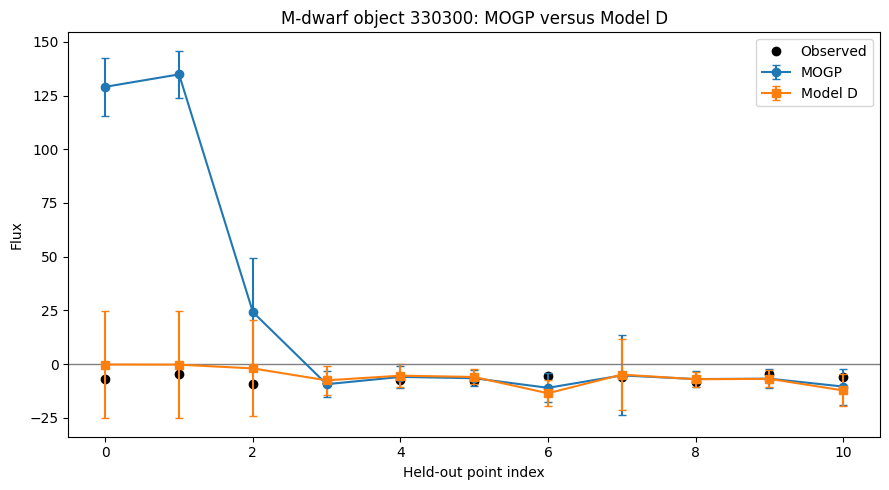

In [8]:
import matplotlib.pyplot as plt

worst_points = worst_points.sort_values("point_index")
x = worst_points["point_index"]

plt.figure(figsize=(9, 5))

plt.plot(x, worst_points["y_true"], "ko", label="Observed")

plt.errorbar(
    x,
    worst_points["mu_mogp"],
    yerr=worst_points["sigma_mogp"],
    fmt="o-",
    capsize=3,
    label="MOGP",
)

plt.errorbar(
    x,
    worst_points["mu_model_d"],
    yerr=worst_points["sigma_model_d"],
    fmt="s-",
    capsize=3,
    label="Model D",
)

plt.axhline(0, color="grey", linewidth=1)
plt.xlabel("Held-out point index")
plt.ylabel("Flux")
plt.title(f"M-dwarf object {worst_id}: MOGP versus Model D")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print("Number of results:", len(all_ablation_results))

print([
    (result.get("object_id"), type(result.get("object_id")))
    for result in all_ablation_results[:10]
])

Number of results: 500
[(np.str_('21846282'), <class 'numpy.str_'>), (np.str_('114421739'), <class 'numpy.str_'>), (np.str_('30652072'), <class 'numpy.str_'>), (np.str_('107732897'), <class 'numpy.str_'>), (np.str_('121186562'), <class 'numpy.str_'>), (np.str_('10905347'), <class 'numpy.str_'>), (np.str_('16775731'), <class 'numpy.str_'>), (np.str_('31971611'), <class 'numpy.str_'>), (np.str_('50875482'), <class 'numpy.str_'>), (np.str_('52437992'), <class 'numpy.str_'>)]


In [11]:
example_match = None
object_id = 330300
target_band = "r"

for object_idx, example in enumerate(selected_examples):
    if str(example["object_id"]) == str(object_id):
        example_match = (object_idx, example)
        break

print("Found in selected_examples:", example_match is not None)

Found in selected_examples: True


In [12]:
object_idx, object_example = example_match

case = run_target_band_ablation_study(
    object_example,
    target_band="r",
    bands=("u", "g", "r", "i", "z"),
    models=(
        "mogp_real_wavelength",
        "mogp_independent_band_control",
    ),
    aux_band_ratios={
        "u": 0.0,
        "g": 0.5,
        "i": 1.0,
        "z": 0.0,
    },
    random_state=object_idx,
    mogp_gp_kwargs={
        "n_restarts_optimizer": 0,
        "print_kernel": False,
    },
)

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


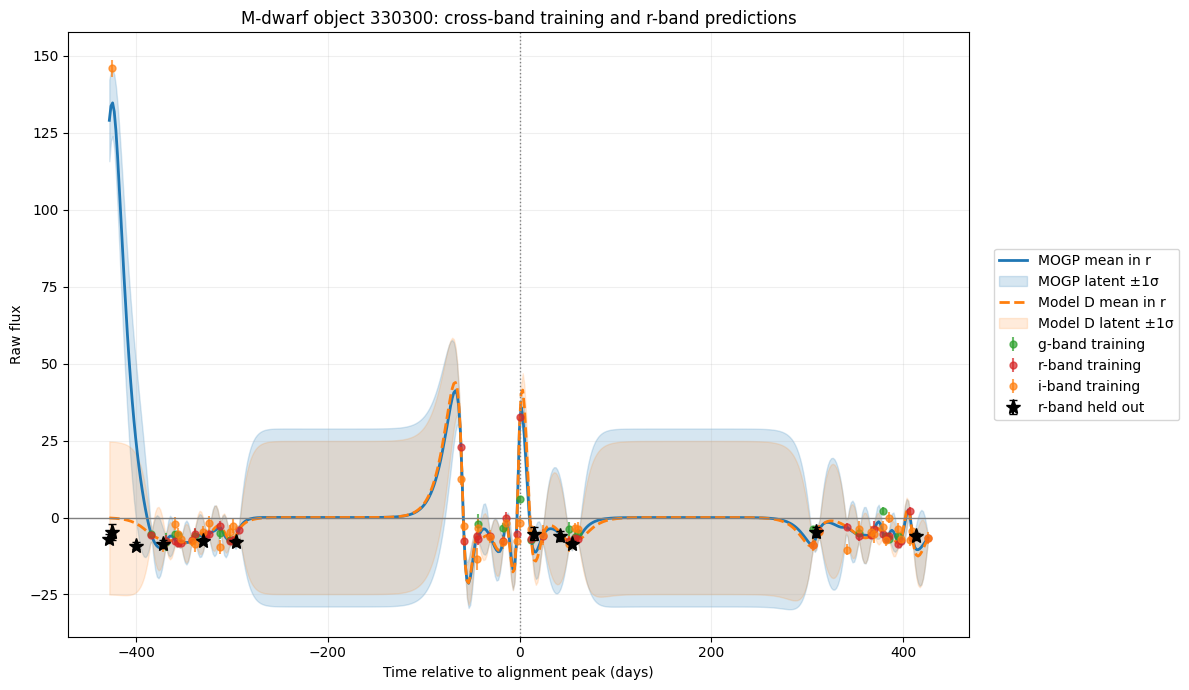

In [13]:
from MOGP_model import DEFAULT_BAND_TO_WAVELENGTH, _resolve_wavelength

mogp_artifact = case["artifacts"]["mogp_real_wavelength"]
model_d_artifact = case["artifacts"]["mogp_independent_band_control"]

gp_mogp = mogp_artifact["gp"]
gp_model_d = model_d_artifact["gp"]

# Both models used these exact same training and held-out rows.
train_data = mogp_artifact["train_data"]
heldout_data = mogp_artifact["heldout_data"]

t_train = np.asarray(train_data["t"], dtype=float)
t_test = np.asarray(heldout_data["t"], dtype=float)

t_scale = float(train_data["t_scale"])
flux_scale = float(train_data["flux_scale"])
background = float(np.asarray(train_data["background_flux"]).reshape(-1)[0])

# Display time relative to the alignment peak in days.
time_train = t_train * t_scale
time_test = t_test * t_scale

# Dense target-band prediction grid.
t_grid = np.linspace(
    min(t_train.min(), t_test.min()),
    max(t_train.max(), t_test.max()),
    500,
)

target_wavelength = _resolve_wavelength(
    target_band,
    DEFAULT_BAND_TO_WAVELENGTH,
)

X_grid = np.column_stack([
    t_grid,
    np.full(len(t_grid), target_wavelength),
])

mu_mogp_norm, std_mogp_norm = gp_mogp.predict(
    X_grid,
    return_std=True,
)
mu_model_d_norm, std_model_d_norm = gp_model_d.predict(
    X_grid,
    return_std=True,
)

# Return dense predictions to raw-flux space.
mu_mogp = mu_mogp_norm * flux_scale + background
std_mogp = std_mogp_norm * flux_scale

mu_model_d = mu_model_d_norm * flux_scale + background
std_model_d = std_model_d_norm * flux_scale

time_grid = t_grid * t_scale

band_colors = {
    "u": "tab:purple",
    "g": "tab:green",
    "r": "tab:red",
    "i": "tab:orange",
    "z": "tab:brown",
}

fig, ax = plt.subplots(figsize=(12, 7))

# Plot all training observations, colored by band.
train_bands = np.asarray(train_data["band"], dtype=object)
train_flux = np.asarray(train_data["y_raw"], dtype=float)
train_error = np.asarray(train_data["yerr_raw"], dtype=float)

for band in sorted(
    np.unique(train_bands),
    key=lambda b: _resolve_wavelength(
        b,
        DEFAULT_BAND_TO_WAVELENGTH,
    ),
):
    mask = train_bands.astype(str) == str(band)

    ax.errorbar(
        time_train[mask],
        train_flux[mask],
        yerr=train_error[mask],
        fmt="o",
        markersize=5,
        alpha=0.7,
        color=band_colors.get(str(band), None),
        ecolor=band_colors.get(str(band), None),
        label=f"{band}-band training",
    )

# Target-band held-out observations.
test_bands = np.asarray(heldout_data["band"], dtype=object)
target_test = test_bands.astype(str) == str(target_band)

ax.errorbar(
    time_test[target_test],
    np.asarray(heldout_data["y_raw"])[target_test],
    yerr=np.asarray(heldout_data["yerr_raw"])[target_test],
    fmt="*",
    markersize=11,
    color="black",
    ecolor="black",
    capsize=3,
    label=f"{target_band}-band held out",
    zorder=10,
)

# Standard MOGP.
ax.plot(
    time_grid,
    mu_mogp,
    color="tab:blue",
    linewidth=2,
    label="MOGP mean in r",
)
ax.fill_between(
    time_grid,
    mu_mogp - std_mogp,
    mu_mogp + std_mogp,
    color="tab:blue",
    alpha=0.18,
    label="MOGP latent ±1σ",
)

# Independent-band Model D.
ax.plot(
    time_grid,
    mu_model_d,
    color="tab:orange",
    linewidth=2,
    linestyle="--",
    label="Model D mean in r",
)
ax.fill_between(
    time_grid,
    mu_model_d - std_model_d,
    mu_model_d + std_model_d,
    color="tab:orange",
    alpha=0.15,
    label="Model D latent ±1σ",
)

ax.axvline(0, color="grey", linestyle=":", linewidth=1)
ax.axhline(0, color="grey", linewidth=1)

ax.set(
    title=f"M-dwarf object {object_id}: cross-band training and r-band predictions",
    xlabel="Time relative to alignment peak (days)",
    ylabel="Raw flux",
)

ax.grid(alpha=0.2)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
fig.tight_layout()
plt.show()

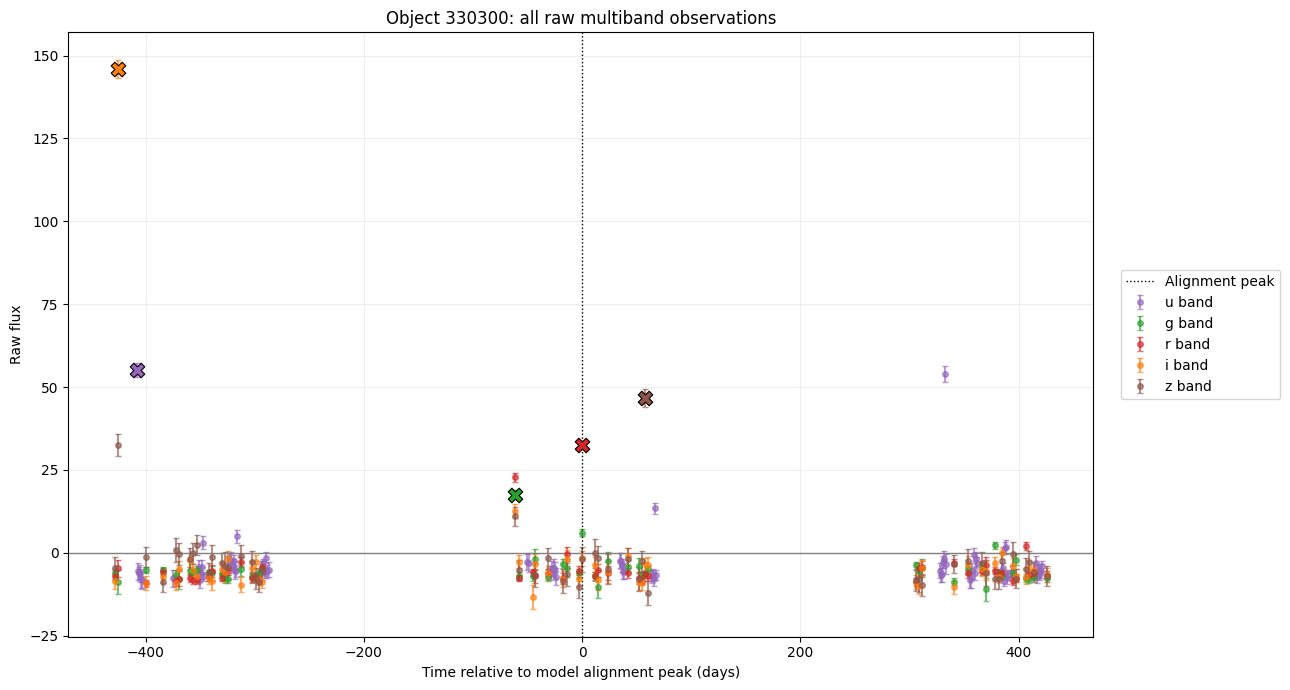

In [14]:
object_id = 330300

# Find the original object record.
object_example = next(
    example
    for example in selected_examples
    if str(example["object_id"]) == str(object_id)
)

lc = object_example["lightcurve"]

raw_time = np.asarray(lc["time"], dtype=float)
raw_flux = np.asarray(lc["flux"], dtype=float)
raw_flux_err = np.asarray(lc["flux_err"], dtype=float)
raw_band = np.asarray(lc["band"], dtype=object)

valid = (
    np.isfinite(raw_time)
    & np.isfinite(raw_flux)
    & np.isfinite(raw_flux_err)
    & (raw_flux_err > 0)
)

raw_time = raw_time[valid]
raw_flux = raw_flux[valid]
raw_flux_err = raw_flux_err[valid]
raw_band = raw_band[valid]

# Use the exact alignment peak employed by the ablation models.
alignment_peak_time = float(
    case["artifacts"]["mogp_real_wavelength"]
        ["train_data"]["alignment_peak_time"]
)

time_relative = raw_time - alignment_peak_time

band_colors = {
    "u": "tab:purple",
    "g": "tab:green",
    "r": "tab:red",
    "i": "tab:orange",
    "z": "tab:brown",
    "Y": "tab:gray",
    "y": "tab:gray",
}

band_order = ["u", "g", "r", "i", "z", "Y"]

fig, ax = plt.subplots(figsize=(13, 7))

for band in band_order:
    mask = raw_band.astype(str) == band

    if not np.any(mask):
        continue

    order = np.argsort(time_relative[mask])

    band_time = time_relative[mask][order]
    band_flux = raw_flux[mask][order]
    band_error = raw_flux_err[mask][order]

    ax.errorbar(
        band_time,
        band_flux,
        yerr=band_error,
        fmt="o",
        markersize=4,
        capsize=2,
        alpha=0.65,
        color=band_colors.get(band),
        ecolor=band_colors.get(band),
        label=f"{band} band",
    )

    # Mark the largest positive-flux observation in each band.
    peak_index = np.argmax(band_flux)

    ax.scatter(
        band_time[peak_index],
        band_flux[peak_index],
        marker="X",
        s=110,
        color=band_colors.get(band),
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )

ax.axvline(
    0,
    color="black",
    linestyle=":",
    linewidth=1,
    label="Alignment peak",
)
ax.axhline(0, color="grey", linewidth=1)

ax.set(
    title=f"Object {object_id}: all raw multiband observations",
    xlabel="Time relative to model alignment peak (days)",
    ylabel="Raw flux",
)

ax.grid(alpha=0.2)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
fig.tight_layout()
plt.show()

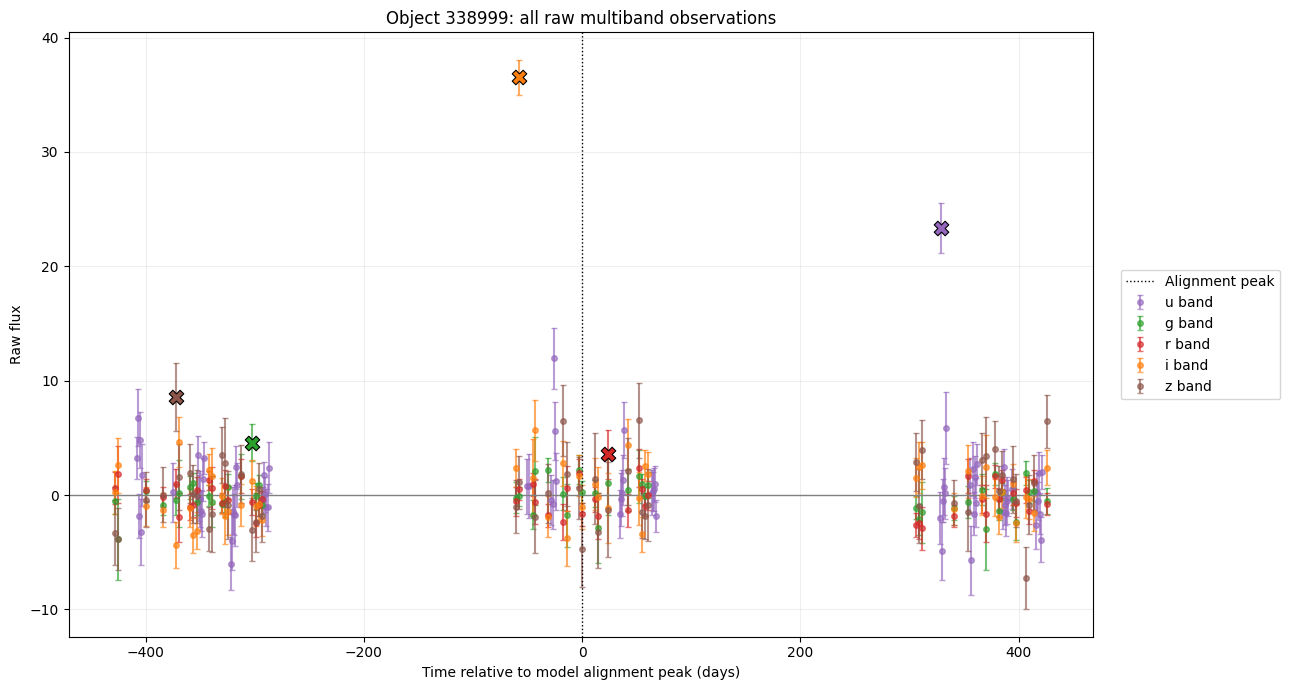

In [16]:
object_id = 338999

# Find the original object record.
object_example = next(
    example
    for example in selected_examples
    if str(example["object_id"]) == str(object_id)
)

lc = object_example["lightcurve"]

raw_time = np.asarray(lc["time"], dtype=float)
raw_flux = np.asarray(lc["flux"], dtype=float)
raw_flux_err = np.asarray(lc["flux_err"], dtype=float)
raw_band = np.asarray(lc["band"], dtype=object)

valid = (
    np.isfinite(raw_time)
    & np.isfinite(raw_flux)
    & np.isfinite(raw_flux_err)
    & (raw_flux_err > 0)
)

raw_time = raw_time[valid]
raw_flux = raw_flux[valid]
raw_flux_err = raw_flux_err[valid]
raw_band = raw_band[valid]

# Use the exact alignment peak employed by the ablation models.
alignment_peak_time = float(
    case["artifacts"]["mogp_real_wavelength"]
        ["train_data"]["alignment_peak_time"]
)

time_relative = raw_time - alignment_peak_time

band_colors = {
    "u": "tab:purple",
    "g": "tab:green",
    "r": "tab:red",
    "i": "tab:orange",
    "z": "tab:brown",
    "Y": "tab:gray",
    "y": "tab:gray",
}

band_order = ["u", "g", "r", "i", "z", "Y"]

fig, ax = plt.subplots(figsize=(13, 7))

for band in band_order:
    mask = raw_band.astype(str) == band

    if not np.any(mask):
        continue

    order = np.argsort(time_relative[mask])

    band_time = time_relative[mask][order]
    band_flux = raw_flux[mask][order]
    band_error = raw_flux_err[mask][order]

    ax.errorbar(
        band_time,
        band_flux,
        yerr=band_error,
        fmt="o",
        markersize=4,
        capsize=2,
        alpha=0.65,
        color=band_colors.get(band),
        ecolor=band_colors.get(band),
        label=f"{band} band",
    )

    # Mark the largest positive-flux observation in each band.
    peak_index = np.argmax(band_flux)

    ax.scatter(
        band_time[peak_index],
        band_flux[peak_index],
        marker="X",
        s=110,
        color=band_colors.get(band),
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )

ax.axvline(
    0,
    color="black",
    linestyle=":",
    linewidth=1,
    label="Alignment peak",
)
ax.axhline(0, color="grey", linewidth=1)

ax.set(
    title=f"Object {object_id}: all raw multiband observations",
    xlabel="Time relative to model alignment peak (days)",
    ylabel="Raw flux",
)

ax.grid(alpha=0.2)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
fig.tight_layout()
plt.show()

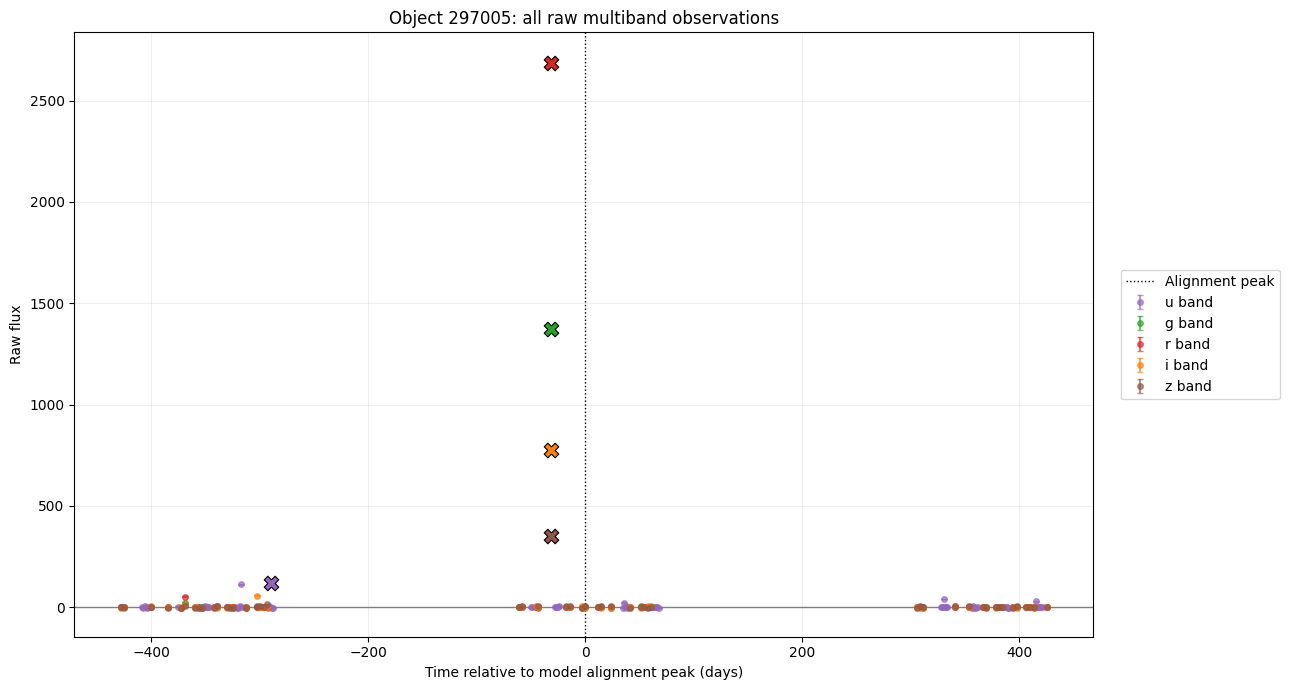

In [17]:
object_id = 297005

# Find the original object record.
object_example = next(
    example
    for example in selected_examples
    if str(example["object_id"]) == str(object_id)
)

lc = object_example["lightcurve"]

raw_time = np.asarray(lc["time"], dtype=float)
raw_flux = np.asarray(lc["flux"], dtype=float)
raw_flux_err = np.asarray(lc["flux_err"], dtype=float)
raw_band = np.asarray(lc["band"], dtype=object)

valid = (
    np.isfinite(raw_time)
    & np.isfinite(raw_flux)
    & np.isfinite(raw_flux_err)
    & (raw_flux_err > 0)
)

raw_time = raw_time[valid]
raw_flux = raw_flux[valid]
raw_flux_err = raw_flux_err[valid]
raw_band = raw_band[valid]

# Use the exact alignment peak employed by the ablation models.
alignment_peak_time = float(
    case["artifacts"]["mogp_real_wavelength"]
        ["train_data"]["alignment_peak_time"]
)

time_relative = raw_time - alignment_peak_time

band_colors = {
    "u": "tab:purple",
    "g": "tab:green",
    "r": "tab:red",
    "i": "tab:orange",
    "z": "tab:brown",
    "Y": "tab:gray",
    "y": "tab:gray",
}

band_order = ["u", "g", "r", "i", "z", "Y"]

fig, ax = plt.subplots(figsize=(13, 7))

for band in band_order:
    mask = raw_band.astype(str) == band

    if not np.any(mask):
        continue

    order = np.argsort(time_relative[mask])

    band_time = time_relative[mask][order]
    band_flux = raw_flux[mask][order]
    band_error = raw_flux_err[mask][order]

    ax.errorbar(
        band_time,
        band_flux,
        yerr=band_error,
        fmt="o",
        markersize=4,
        capsize=2,
        alpha=0.65,
        color=band_colors.get(band),
        ecolor=band_colors.get(band),
        label=f"{band} band",
    )

    # Mark the largest positive-flux observation in each band.
    peak_index = np.argmax(band_flux)

    ax.scatter(
        band_time[peak_index],
        band_flux[peak_index],
        marker="X",
        s=110,
        color=band_colors.get(band),
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )

ax.axvline(
    0,
    color="black",
    linestyle=":",
    linewidth=1,
    label="Alignment peak",
)
ax.axhline(0, color="grey", linewidth=1)

ax.set(
    title=f"Object {object_id}: all raw multiband observations",
    xlabel="Time relative to model alignment peak (days)",
    ylabel="Raw flux",
)

ax.grid(alpha=0.2)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
fig.tight_layout()
plt.show()

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.w

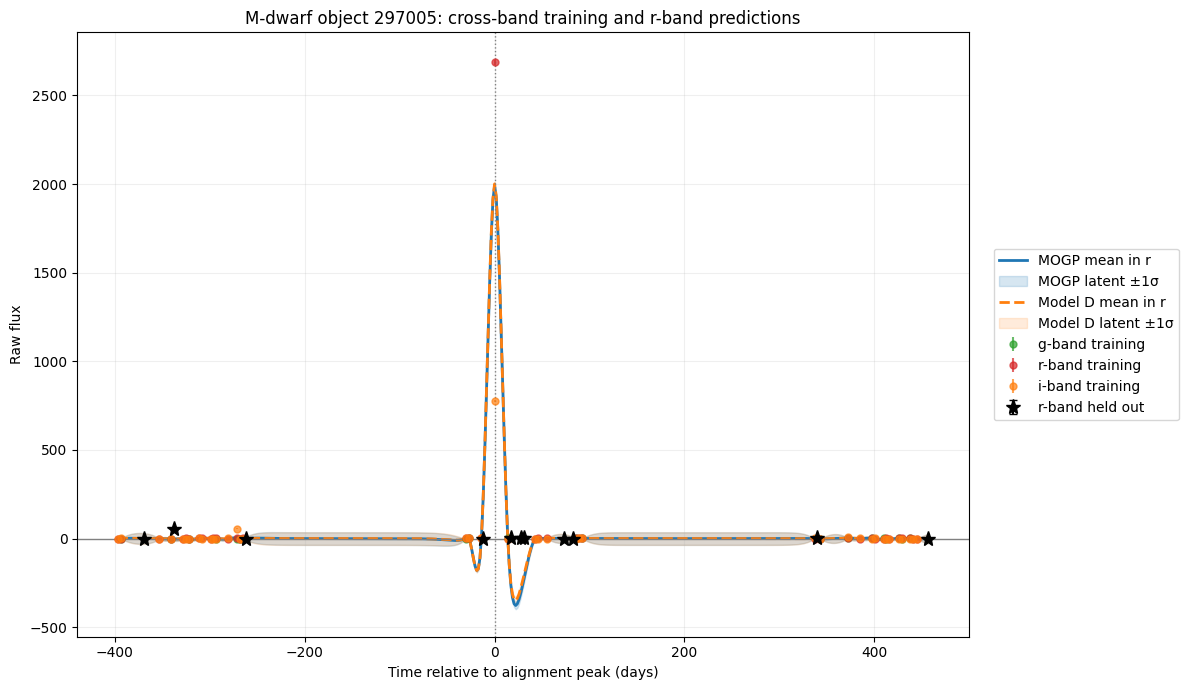

In [18]:
example_match = None
object_id = 297005
target_band = "r"

for object_idx, example in enumerate(selected_examples):
    if str(example["object_id"]) == str(object_id):
        example_match = (object_idx, example)
        break

object_idx, object_example = example_match

case = run_target_band_ablation_study(
    object_example,
    target_band="r",
    bands=("u", "g", "r", "i", "z"),
    models=(
        "mogp_real_wavelength",
        "mogp_independent_band_control",
    ),
    aux_band_ratios={
        "u": 0.0,
        "g": 0.5,
        "i": 1.0,
        "z": 0.0,
    },
    random_state=object_idx,
    mogp_gp_kwargs={
        "n_restarts_optimizer": 0,
        "print_kernel": False,
    },
)

from MOGP_model import DEFAULT_BAND_TO_WAVELENGTH, _resolve_wavelength

mogp_artifact = case["artifacts"]["mogp_real_wavelength"]
model_d_artifact = case["artifacts"]["mogp_independent_band_control"]

gp_mogp = mogp_artifact["gp"]
gp_model_d = model_d_artifact["gp"]

# Both models used these exact same training and held-out rows.
train_data = mogp_artifact["train_data"]
heldout_data = mogp_artifact["heldout_data"]

t_train = np.asarray(train_data["t"], dtype=float)
t_test = np.asarray(heldout_data["t"], dtype=float)

t_scale = float(train_data["t_scale"])
flux_scale = float(train_data["flux_scale"])
background = float(np.asarray(train_data["background_flux"]).reshape(-1)[0])

# Display time relative to the alignment peak in days.
time_train = t_train * t_scale
time_test = t_test * t_scale

# Dense target-band prediction grid.
t_grid = np.linspace(
    min(t_train.min(), t_test.min()),
    max(t_train.max(), t_test.max()),
    500,
)

target_wavelength = _resolve_wavelength(
    target_band,
    DEFAULT_BAND_TO_WAVELENGTH,
)

X_grid = np.column_stack([
    t_grid,
    np.full(len(t_grid), target_wavelength),
])

mu_mogp_norm, std_mogp_norm = gp_mogp.predict(
    X_grid,
    return_std=True,
)
mu_model_d_norm, std_model_d_norm = gp_model_d.predict(
    X_grid,
    return_std=True,
)

# Return dense predictions to raw-flux space.
mu_mogp = mu_mogp_norm * flux_scale + background
std_mogp = std_mogp_norm * flux_scale

mu_model_d = mu_model_d_norm * flux_scale + background
std_model_d = std_model_d_norm * flux_scale

time_grid = t_grid * t_scale

band_colors = {
    "u": "tab:purple",
    "g": "tab:green",
    "r": "tab:red",
    "i": "tab:orange",
    "z": "tab:brown",
}

fig, ax = plt.subplots(figsize=(12, 7))

# Plot all training observations, colored by band.
train_bands = np.asarray(train_data["band"], dtype=object)
train_flux = np.asarray(train_data["y_raw"], dtype=float)
train_error = np.asarray(train_data["yerr_raw"], dtype=float)

for band in sorted(
    np.unique(train_bands),
    key=lambda b: _resolve_wavelength(
        b,
        DEFAULT_BAND_TO_WAVELENGTH,
    ),
):
    mask = train_bands.astype(str) == str(band)

    ax.errorbar(
        time_train[mask],
        train_flux[mask],
        yerr=train_error[mask],
        fmt="o",
        markersize=5,
        alpha=0.7,
        color=band_colors.get(str(band), None),
        ecolor=band_colors.get(str(band), None),
        label=f"{band}-band training",
    )

# Target-band held-out observations.
test_bands = np.asarray(heldout_data["band"], dtype=object)
target_test = test_bands.astype(str) == str(target_band)

ax.errorbar(
    time_test[target_test],
    np.asarray(heldout_data["y_raw"])[target_test],
    yerr=np.asarray(heldout_data["yerr_raw"])[target_test],
    fmt="*",
    markersize=11,
    color="black",
    ecolor="black",
    capsize=3,
    label=f"{target_band}-band held out",
    zorder=10,
)

# Standard MOGP.
ax.plot(
    time_grid,
    mu_mogp,
    color="tab:blue",
    linewidth=2,
    label="MOGP mean in r",
)
ax.fill_between(
    time_grid,
    mu_mogp - std_mogp,
    mu_mogp + std_mogp,
    color="tab:blue",
    alpha=0.18,
    label="MOGP latent ±1σ",
)

# Independent-band Model D.
ax.plot(
    time_grid,
    mu_model_d,
    color="tab:orange",
    linewidth=2,
    linestyle="--",
    label="Model D mean in r",
)
ax.fill_between(
    time_grid,
    mu_model_d - std_model_d,
    mu_model_d + std_model_d,
    color="tab:orange",
    alpha=0.15,
    label="Model D latent ±1σ",
)

ax.axvline(0, color="grey", linestyle=":", linewidth=1)
ax.axhline(0, color="grey", linewidth=1)

ax.set(
    title=f"M-dwarf object {object_id}: cross-band training and r-band predictions",
    xlabel="Time relative to alignment peak (days)",
    ylabel="Raw flux",
)

ax.grid(alpha=0.2)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
fig.tight_layout()
plt.show()